In [1]:
import os
import sys
from datetime import datetime
import json

sys.path.append(os.path.abspath('..'))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # 0=all messages, 1=information, 2=warning, 3=error

env_path = sys.prefix
os.environ['CC'] = f"{env_path}/bin/x86_64-conda-linux-gnu-cc"
os.environ['CXX'] = f"{env_path}/bin/x86_64-conda-linux-gnu-c++"

os.environ['PKG_CONFIG_PATH'] = f"{env_path}/lib/pkgconfig"
os.environ['LD_LIBRARY_PATH'] = f"{env_path}/lib"

os.makedirs('data/models/weights', exist_ok=True)
os.makedirs('data/models/histories', exist_ok=True)

pipeline_id = datetime.now().strftime("%Y%m%d_%H%M%S")
pipeline_file = 'data/models/current_pipeline_id.json'
os.makedirs(os.path.dirname(pipeline_file), exist_ok=True)
with open(pipeline_file, 'w') as f:
    json.dump({'latest_id': pipeline_id}, f)

In [2]:
import tensorflow as tf
import numpy as np
import random

from src.networks.DecoderPINN import PINN
from src.optimization.DecoderTrainer import DecoderTrainer
from src.data.dataloader import load_parametric_fem_data
from src.data.collocation import generate_parametric_collocation_points
from src.physics.physics import get_M_dynamic
from src.visualization.historyplots import plot_adam_history
from src.visualization.pdeplots import get_eval_grid, plot_parametric_pinn_solution
from src.hyperparameters import hypers_uqvae as h

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

tf.keras.backend.set_floatx('float32')
number_type = tf.float32

2026-09-10 16:20:17.452144: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789050017.465721  152393 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789050017.470361  152393 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1789050017.481561  152393 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789050017.481575  152393 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789050017.481576  152393 computation_placer.cc:177] computation placer alr

In [3]:
train_path = 'data/fem/fem_parametric_train.npz'
val_path = 'data/fem/fem_parametric_val.npz'
test_path = 'data/fem/fem_parametric_test.npz'
scale_save_path = 'data/models/u_scale_var.npy'

# Load parametric FEM data
(x_train_pinn, u_train_pinn), (x_val_pinn, u_val_pinn), (x_test_pinn, u_test_pinn), U_SCALE = load_parametric_fem_data(
    train_path=train_path,
    val_path=val_path,
    test_path=test_path,
    scale_save_path=scale_save_path,
    noise_level=h.NOISE,
    dtype=number_type
)

Loading Parametric FEM data from:
data/fem/fem_parametric_train.npz
data/fem/fem_parametric_val.npz
data/fem/fem_parametric_test.npz
U_SCALE: 0.07060286428244116


I0000 00:00:1789050019.847341  152393 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5276 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0


Injected Gaussian noise with stddev: 0.02
Shape x_train: (813960, 4)
Shape x_val:   (100980, 4)
Shape x_test:  (103020, 4)


In [4]:
# Model creation
model = PINN(h.N_NEURONS_DECODER, U_SCALE)
model(tf.zeros((1, 4)))  # 4 input [x, y, cx, cy]

with open('data/models/current_pipeline_id.json', 'r') as f:
    pipeline_id = json.load(f)['latest_id']

# Optimizer
initial_learning_rate = 1e-3
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=1000,      
    decay_rate=0.8,        
    staircase=False        
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
optimizer.build(model.trainable_variables)

In [5]:
N_interior = h.N_INTERIOR_ADAM
N_boundary = h.N_BOUNDARY_ADAM
N_activation = h.N_ACTIVATION_ADAM


def point_generator_fn():
    return generate_parametric_collocation_points(
        N_interior=N_interior,
        N_boundary=N_boundary,
        N_activation=N_activation,
        dtype=number_type)

In [6]:
# LOSS PARAMETERS
lambdas = {
    'pde': h.LAMBDA_PDE_ADAM,
    'neu': h.LAMBDA_NEU_ADAM,
    'dir': h.LAMBDA_DIR_ADAM,
    'data': h.LAMBDA_DATA_ADAM}

trainer = DecoderTrainer(model=model, pipeline_id= pipeline_id)

trainer.train_adam(optimizer=optimizer,
                   epochs=h.EPOCHS_DECODER_ADAM,
                   x_train=x_train_pinn,
                   u_train=u_train_pinn,
                   x_val=x_val_pinn,
                   u_val=u_val_pinn,
                   physics_fn=get_M_dynamic,
                   lambdas=lambdas,
                   point_generator_fn=point_generator_fn,
                   batch_size=h.BATCH_SIZE_DECODER_ADAM,
                   patience=h.PATIENCE_DECODER_ADAM,
                   number_type=number_type)


Starting Adam optimization...


I0000 00:00:1789050023.579113  152393 service.cc:152] XLA service 0x58f6efe8d8d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789050023.579202  152393 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 5080, Compute Capability 12.0
I0000 00:00:1789050024.012733  152393 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1789050027.081395  152393 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch    0 | Loss: 1.5563e+00 | PDE: 5.4410e-05 | Dir: 2.6092e-03 | Neu: 3.2091e-05 | Data: 1.2948e-01 | Val: 1.7918e-02
Epoch  500 | Loss: 3.6170e-02 | PDE: 9.9704e-05 | Dir: 9.8997e-06 | Neu: 5.5067e-05 | Data: 3.4182e-03 | Val: 3.1058e-03
Epoch 1000 | Loss: 1.5034e-02 | PDE: 2.6135e-04 | Dir: 8.4141e-06 | Neu: 8.6825e-05 | Data: 1.1578e-03 | Val: 7.1021e-04
Epoch 1500 | Loss: 1.0737e-02 | PDE: 1.5909e-04 | Dir: 3.8518e-06 | Neu: 7.5409e-05 | Data: 8.7601e-04 | Val: 4.5787e-04
Epoch 2000 | Loss: 1.0090e-02 | PDE: 1.2676e-04 | Dir: 2.1693e-06 | Neu: 7.8846e-05 | Data: 8.6045e-04 | Val: 4.2342e-04
Epoch 2500 | Loss: 8.4286e-03 | PDE: 1.1966e-04 | Dir: 1.6862e-06 | Neu: 8.4200e-05 | Data: 7.0625e-04 | Val: 3.0317e-04
Epoch 3000 | Loss: 7.3618e-03 | PDE: 7.8216e-05 | Dir: 1.7769e-06 | Neu: 8.2834e-05 | Data: 6.4011e-04 | Val: 2.3230e-04
Epoch 3500 | Loss: 6.7789e-03 | PDE: 9.6288e-05 | Dir: 6.6925e-07 | Neu: 6.1966e-05 | Data: 5.7485e-04 | Val: 2.0303e-04
Epoch 4000 | Loss: 6.2675e-03 | 

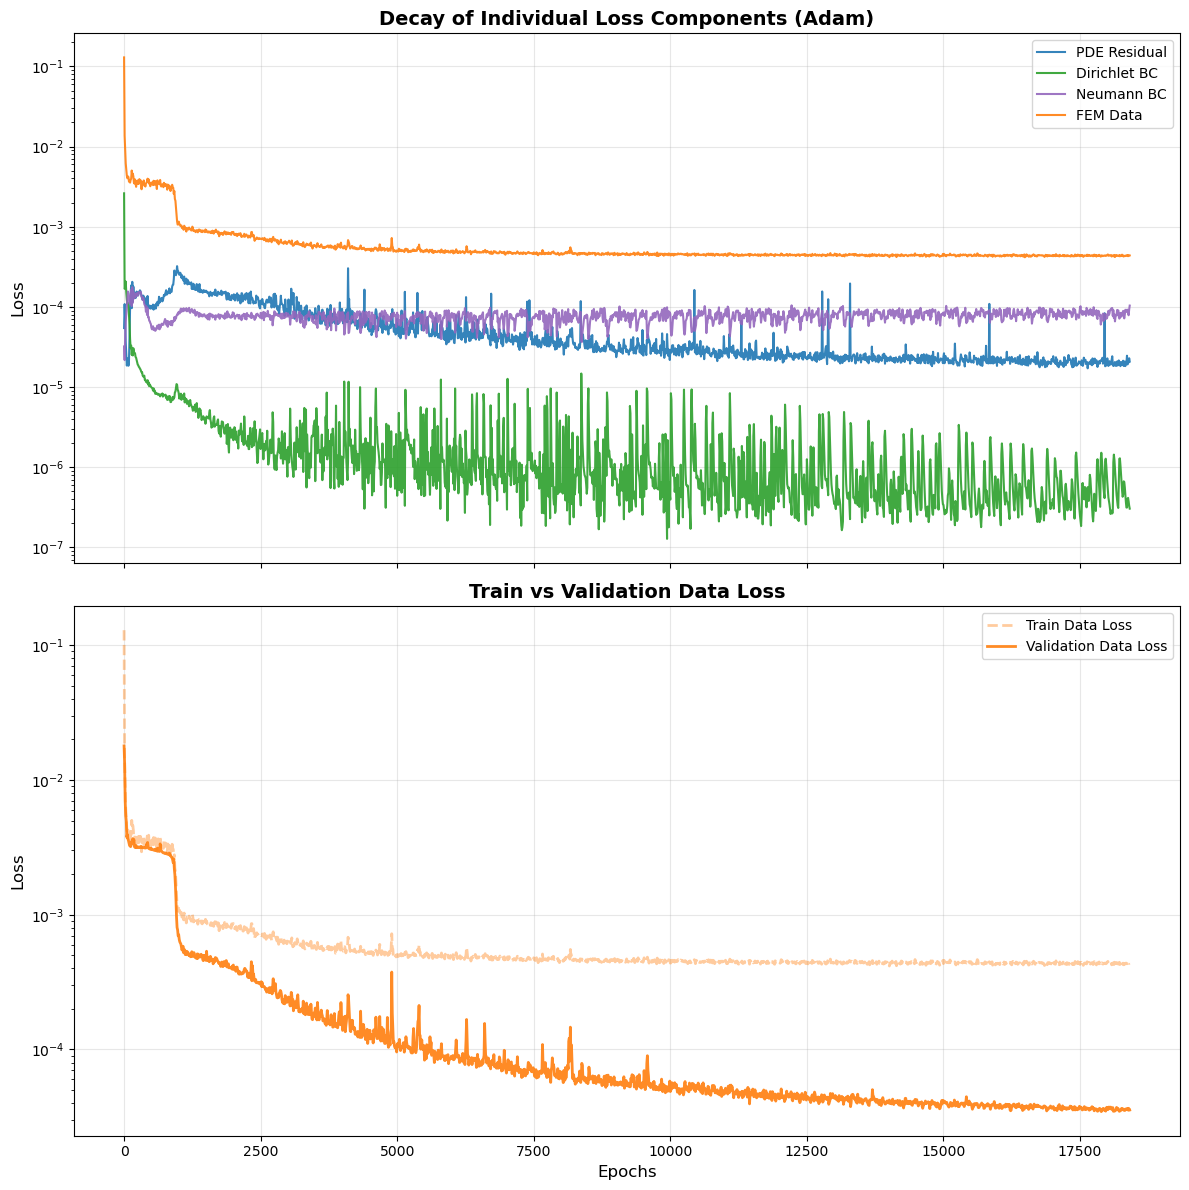

In [7]:
plot_adam_history(trainer.history_adam, save_freq=10)

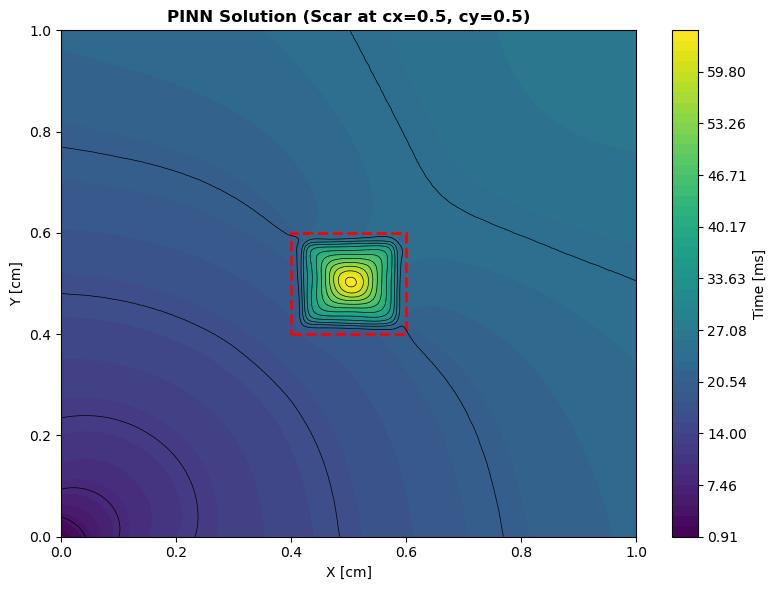

In [8]:
cx_test, cy_test = 0.5, 0.5
X, Y, X_tensor = get_eval_grid(N=400, cx=cx_test, cy=cy_test, dtype=number_type)

u_pred_flat = model(X_tensor).numpy() * U_SCALE
U_PINN = u_pred_flat.reshape(400, 400) * 1000.0

plot_parametric_pinn_solution(X, Y, U_PINN, cx_test, cy_test, lato_cicatrice=0.2)